# Task 2

In [9]:
import abc
import json
import re
from openai import OpenAI
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import os

all_text = ""
with open("mytext.json", "r") as f:
    data = json.load(f)
    all_text = " ".join(data["paragraphs"])
    

class Chunk():
    def __init__(self, text: str, on_stop: bool) -> None:
        self.text = text
        self.on_stop = on_stop
        self.embedding = None
        
    def set_embedding(self, embedding: list[float]) -> None:
        self.embedding = embedding
        
        
class Chunker():
    def __init__(self, chunk_size: int, left_overlap: int, right_overlap: int, detect_stops: bool = False, search_distance: int = 8) -> None:
        self.chunk_size = chunk_size
        self.left_overlap = left_overlap
        self.right_overlap = right_overlap
        self.search_distance = search_distance
        self.detect_stops = detect_stops
        
    def chunk(self, text: str) -> list[Chunk]:
        tokens = text.split()
        start = 0
        end = self.chunk_size
        
        chunks: list[Chunk] = []
        while end < len(tokens):
            on_stop = False
            move = 0
            if self.detect_stops:
                start_search = max(end - self.search_distance, 0)
                end_search = min(end + self.search_distance, len(tokens))
                search_chunk = tokens[start_search:end_search]
                stop_positions = [i for i, token in enumerate(search_chunk) if re.search(r'[.!?;]', token)]
                if stop_positions:
                    new_end = start_search + stop_positions[-1] + 1
                    move = new_end - end
                    end = new_end
                    on_stop = True
                    
            
            chunk = tokens[max(start - self.left_overlap, 0):min(end + self.right_overlap, len(tokens))]
            
            start += self.chunk_size + move
            end += self.chunk_size
            
            joined_text = " ".join(chunk)
            chunks.append(Chunk(joined_text, on_stop))
            
        if start < len(tokens):
            chunk = tokens[max(start - self.left_overlap, 0):len(tokens)] 
            joined_text = " ".join(chunk)
            chunks.append(Chunk(joined_text, False))
        
        return chunks
    
    
class Paragraph():
    def __init__(self, chunks: list[Chunk]) -> None:
        self.chunks = chunks
        
        
class Embedder():
    def __init__(self, client: OpenAI) -> None:
        self.client = client
        self.paragraphs: list[Paragraph] = []

    def get_embeddings(self, texts: list[str], batch_size: int = 256) -> list[list[float]]:
        all_embeddings = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            response = self.client.embeddings.create(
                model="openai/text-embedding-3-small",
                input=batch,
                encoding_format="float"
            )
            batch_embeddings = []
            for item in response.data:
                batch_embeddings.append(item.embedding)
            all_embeddings.extend(batch_embeddings)
        return all_embeddings
    
    def add_paragraph(self, paragraph: Paragraph) -> None:
        self.paragraphs.append(paragraph)
        
    def add_paragraphs(self, paragraphs: list[Paragraph]) -> None:
        self.paragraphs.extend(paragraphs)
        
    def process_paragraphs(self) -> None:
        all_texts = []
        for paragraph in self.paragraphs:
            texts = [chunk.text for chunk in paragraph.chunks]
            all_texts.extend(texts)
        embeddings = self.get_embeddings(all_texts)
        
        # redistribute embeddings back to chunks
        idx = 0
        for paragraph in self.paragraphs:
            for chunk in paragraph.chunks:
                chunk.set_embedding(embeddings[idx])
                idx += 1
                
                
class Loader():
    
    def __init__(self, chunker: Chunker) -> None:
        self.chunker = chunker
        
    def load(self, path: str) -> list[Paragraph]:
        with open(path, "r") as f:
            data = json.load(f)
            paragraphs = []
            for para in data["paragraphs"]:
                chunks = self.chunker.chunk(para)
                paragraphs.append(Paragraph(chunks))
            return paragraphs
        
    def load_str(self, text: str) -> Paragraph:
        """
        Load a paragraph from the text, simple as that!
        """
        chunks = self.chunker.chunk(text)
        return Paragraph(chunks)



class SimilarityFormula(abc.ABC):
    def __init__(self) -> None:
        pass

    @abc.abstractmethod
    def compute_similarity(self, embedding1: np.array, embedding2: np.array) -> float:
        pass


class SimilarityAnalyzer():
    def __init__(self) -> None:
        pass
    
    def compare(
        self,
        paragraphs: list[Paragraph],
        paragraph: Paragraph,
        similarity_equation: SimilarityFormula
    ) -> list[tuple[Paragraph, Paragraph, list[tuple[Chunk, Chunk, float]]]]:
        if not paragraphs:
            raise Exception("No paragraphs provided. Operation aborted.")
        obj_paragraphs = paragraphs
        query_chunks = paragraph.chunks
        if not query_chunks:
            raise Exception("Query paragraph has no chunks. Operation aborted.")

        if any(chunk.embedding is None for p in obj_paragraphs for chunk in p.chunks):
            raise Exception("Embeddings must be set for all chunks before comparison.")

        results = []

        for i, p1 in enumerate(obj_paragraphs):
            for j, p2 in enumerate(obj_paragraphs):
                chunk_pairs: list[tuple[Chunk, Chunk, float]] = []

                for c1 in p1.chunks:
                    emb1 = np.array(c1.embedding)

                    for c2 in p2.chunks:
                        emb2 = np.array(c2.embedding)

                        sim = similarity_equation.compute_similarity(emb1, emb2)
                        chunk_pairs.append((c1, c2, sim))

                results.append((p1, p2, chunk_pairs))
        return results
    
    def extract_top_similar(
        self,
        paragraph: Paragraph,
        results: list[tuple[Paragraph, Paragraph, list[tuple[Chunk, Chunk, float]]]],
        count: int = 5
    ) -> list[Paragraph]:
        """
        Basically look for paragraphs that have the highest similarity. Chunk similarities can be aggregated (e.g. averaged) to get a single similarity score per paragraph pair, and then the top paragraphs can be selected based on those scores. 
        """
        if count <= 0:
            return []

        scored: dict[int, tuple[Paragraph, float]] = {}
        for p1, p2, chunk_pairs in results:
            if not chunk_pairs:
                continue
            if p1 is paragraph:
                other = p2
            elif p2 is paragraph:
                other = p1
            else:
                continue
            if other is paragraph:
                continue
            sims = [float(sim) for _, _, sim in chunk_pairs]
            score = float(np.mean(sims))
            scored[id(other)] = (other, score)

        top = sorted(scored.values(), key=lambda item: item[1], reverse=True)[:count]
        return [p for p, _ in top]


class SimilarityDisplayer():
    
    def __init__(self) -> None:
        pass
    
    def show_paragraph_grid(
        self,
        results: list[tuple[Paragraph, Paragraph, list[tuple[Chunk, Chunk, float]]]],
        paragraphs: list[Paragraph]
    ) -> None:

        if not paragraphs:
            raise Exception("No paragraphs provided. Operation aborted.")

        n = len(paragraphs)
        index_by_paragraph = {id(p): i for i, p in enumerate(paragraphs)}

        matrix = np.zeros((n, n), dtype=np.float32)
        counts = np.zeros((n, n), dtype=np.int32)

        inferred_matrix_size = int(round(np.sqrt(len(results)))) if results else 0
        can_infer_positions = inferred_matrix_size * inferred_matrix_size == len(results)

        for pair_index, (p1, p2, chunk_pairs) in enumerate(results):
            i = index_by_paragraph.get(id(p1))
            j = index_by_paragraph.get(id(p2))
            if i is None or j is None:
                if not can_infer_positions:
                    continue
                i = pair_index // inferred_matrix_size
                j = pair_index % inferred_matrix_size

            if i >= n or j >= n or not chunk_pairs:
                continue

            sims = [float(sim) for _, _, sim in chunk_pairs]
            matrix[i, j] += float(np.mean(sims))
            counts[i, j] += 1

        nonzero = counts > 0
        matrix[nonzero] = matrix[nonzero] / counts[nonzero]

        if np.any(nonzero):
            values = matrix[nonzero]
            vmin, vmax = float(values.min()), float(values.max())
            if vmax > vmin:
                matrix[nonzero] = (matrix[nonzero] - vmin) / (vmax - vmin)
            else:
                matrix[nonzero] = 0.5

        cmap = LinearSegmentedColormap.from_list(
            "black_green_amber",
            [
                (0.00, (0.00, 0.00, 0.00)),
                (0.50, (0.00, 0.65, 0.12)),
                (1.00, (1.00, 0.75, 0.00)),
            ],
        )

        fig, ax = plt.subplots(figsize=(max(6, n * 0.55), max(5, n * 0.55)))
        heatmap = ax.imshow(matrix, cmap=cmap, vmin=0.0, vmax=1.0, interpolation="nearest")

        ax.set_xticks(range(n))
        ax.set_yticks(range(n))
        labels = [f"P{i}" for i in range(n)]
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)

        ax.set_xlabel("Paragraph")
        ax.set_ylabel("Paragraph")
        ax.set_title("Paragraph-to-paragraph similarity")

        cbar = fig.colorbar(heatmap, ax=ax)
        cbar.set_label("Relative similarity")

        plt.tight_layout()
        plt.show()

    def show_chunk_grids_by_paragraph_pair(
        self,
        results: list[tuple[Paragraph, Paragraph, list[tuple[Chunk, Chunk, float]]]],
        paragraphs: list[Paragraph] | None = None,
        max_pairs: int | None = None
    ) -> None:
        cmap = LinearSegmentedColormap.from_list(
            "black_green_amber",
            [
                (0.00, (0.00, 0.00, 0.00)),
                (0.50, (0.00, 0.65, 0.12)),
                (1.00, (1.00, 0.75, 0.00)),
            ],
        )

        paragraph_index = {}
        if paragraphs is not None:
            paragraph_index = {id(p): i for i, p in enumerate(paragraphs)}

        def _short_text(text: str, limit: int = 220) -> str:
            cleaned = " ".join(text.split())
            if len(cleaned) <= limit:
                return cleaned
            return cleaned[: limit - 3] + "..."

        shown = 0
        for p1, p2, chunk_pairs in results:
            if max_pairs is not None and shown >= max_pairs:
                break
            if not chunk_pairs:
                continue

            n1 = len(p1.chunks)
            n2 = len(p2.chunks)
            if n1 == 0 or n2 == 0:
                continue

            idx1 = {id(c): i for i, c in enumerate(p1.chunks)}
            idx2 = {id(c): j for j, c in enumerate(p2.chunks)}

            matrix = np.zeros((n1, n2), dtype=np.float32)
            counts = np.zeros((n1, n2), dtype=np.int32)

            for c1, c2, sim in chunk_pairs:
                i = idx1.get(id(c1))
                j = idx2.get(id(c2))
                if i is None or j is None:
                    continue
                matrix[i, j] += float(sim)
                counts[i, j] += 1

            filled = counts > 0
            if not np.any(filled):
                continue

            matrix[filled] = matrix[filled] / counts[filled]
            values = matrix[filled]
            vmin, vmax = float(values.min()), float(values.max())
            if vmax > vmin:
                matrix[filled] = (matrix[filled] - vmin) / (vmax - vmin)
            else:
                matrix[filled] = 0.5

            p1_idx = paragraph_index.get(id(p1), "?")
            p2_idx = paragraph_index.get(id(p2), "?")

            best_c1, best_c2, best_sim = max(chunk_pairs, key=lambda x: x[2])
            best_i = idx1.get(id(best_c1), "?")
            best_j = idx2.get(id(best_c2), "?")

            p1_text = _short_text(" ".join(c.text for c in p1.chunks))
            p2_text = _short_text(" ".join(c.text for c in p2.chunks))
            best_c1_text = _short_text(best_c1.text)
            best_c2_text = _short_text(best_c2.text)

            fig, ax = plt.subplots(figsize=(max(5, n2 * 0.35), max(4, n1 * 0.35)))
            heatmap = ax.imshow(matrix, cmap=cmap, vmin=0.0, vmax=1.0, interpolation="nearest", aspect="auto")

            ax.set_xticks(range(n2))
            ax.set_yticks(range(n1))
            ax.set_xticklabels([f"c{j}" for j in range(n2)], rotation=45, ha="right")
            ax.set_yticklabels([f"c{i}" for i in range(n1)])

            ax.set_xlabel(f"P{p2_idx} chunks")
            ax.set_ylabel(f"P{p1_idx} chunks")
            ax.set_title(f"Chunk similarity grid: P{p1_idx} vs P{p2_idx}")

            cbar = fig.colorbar(heatmap, ax=ax)
            cbar.set_label("Relative similarity")

            plt.tight_layout()
            plt.show()

            print(f"\n=== P{p1_idx} vs P{p2_idx} ===")
            print(f"P{p1_idx} text: {p1_text}")
            print(f"P{p2_idx} text: {p2_text}")
            print(f"Most similar chunks (score={best_sim:.4f}): P{p1_idx} c{best_i} <-> P{p2_idx} c{best_j}")
            print(f"P{p1_idx} c{best_i}: {best_c1_text}")
            print(f"P{p2_idx} c{best_j}: {best_c2_text}")

            shown += 1
            
            
class Model():
    def __init__(self, client: OpenAI) -> None:
        self.client = client
        
    def generate_text(self, prompt: Paragraph) -> str:
        prompt_text = " ".join(chunk.text for chunk in prompt.chunks)
        response = self.client.chat.completions.create(
            model="openai/gpt-oss-120b",
            messages=[{"role": "user", "content": prompt_text}]
        )
        return response.choices[0].message.content
    
    def generate_text_with_rag(
        self,
        prompt: Paragraph,
        results: list[tuple[Paragraph, Paragraph, list[tuple[Chunk, Chunk, float]]]],
        count: int = 5
    ):
        analyzer = SimilarityAnalyzer()
        top_paragraphs = analyzer.extract_top_similar(prompt, results, count)
        retrieved_text = "\n\n".join(" ".join(chunk.text for chunk in p.chunks) for p in top_paragraphs)
        prompt_text = " ".join(chunk.text for chunk in prompt.chunks)
        full_prompt = f"Context:\n{retrieved_text}\n\nQuestion:\n{prompt_text}\n\nAnswer:"
        response = self.client.chat.completions.create(
            model="openai/gpt-oss-120b",
            messages=[{"role": "user", "content": full_prompt}]
        )
        return response.choices[0].message.content


In [10]:
class cosine_similarity(SimilarityFormula):
    def compute_similarity(self, embedding1, embedding2):
        denom = np.linalg.norm(embedding1) * np.linalg.norm(embedding2)
        if denom == 0:
            return 0.0
        return np.dot(embedding1, embedding2) / denom
    
class euclidean_similarity(SimilarityFormula):
    def compute_similarity(self, embedding1, embedding2): # type: ignore
        return 1 / (1 + np.linalg.norm(embedding1 - embedding2))
    
class dot_similarity(SimilarityFormula):
    def compute_similarity(self, embedding1, embedding2):
        return np.dot(embedding1, embedding2)

class manhattan_similarity(SimilarityFormula):
    def compute_similarity(self, embedding1, embedding2):
        return 1 / (1 + np.sum(np.abs(embedding1 - embedding2)))

In [11]:
openai_token = os.getenv("OPENROUTER_API_KEY")

client = OpenAI(
    api_key=openai_token,
    base_url="https://openrouter.ai/api/v1",
)

chunker = Chunker(64, 4, 4, True, 16)
manager = Embedder(client)
loader = Loader(chunker)
paragraphs = loader.load("mytext.json")

quest_1_text = "Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?"
quest_2_text = "According to the May 2026 Reporters Without Borders report, what was the primary reason cited for the United States falling to its lowest-ever press freedom ranking of 64th?"
quest_3_text = "What were the names of the two specific locations in Lithuania where railway derailments occurred within a three-day period in early May 2026?"
quest_4_text = "In the May 2026 IIHF World Championship games, which specific player scored Lithuania's lone goal against Ukraine, and which North American junior team did he previously play for?"
quest_5_text = "Which three specific financial and investment firms did Anthropic partner with in May 2026 to launch their new enterprise AI integration company?"

quest_1 = loader.load_str(quest_1_text)
quest_2 = loader.load_str(quest_2_text)
quest_3 = loader.load_str(quest_3_text)
quest_4 = loader.load_str(quest_4_text)
quest_5 = loader.load_str(quest_5_text)

list_of_quests = [quest_1, quest_2, quest_3, quest_4, quest_5]
manager.add_paragraphs(list_of_quests)
manager.add_paragraphs(paragraphs)
manager.process_paragraphs()

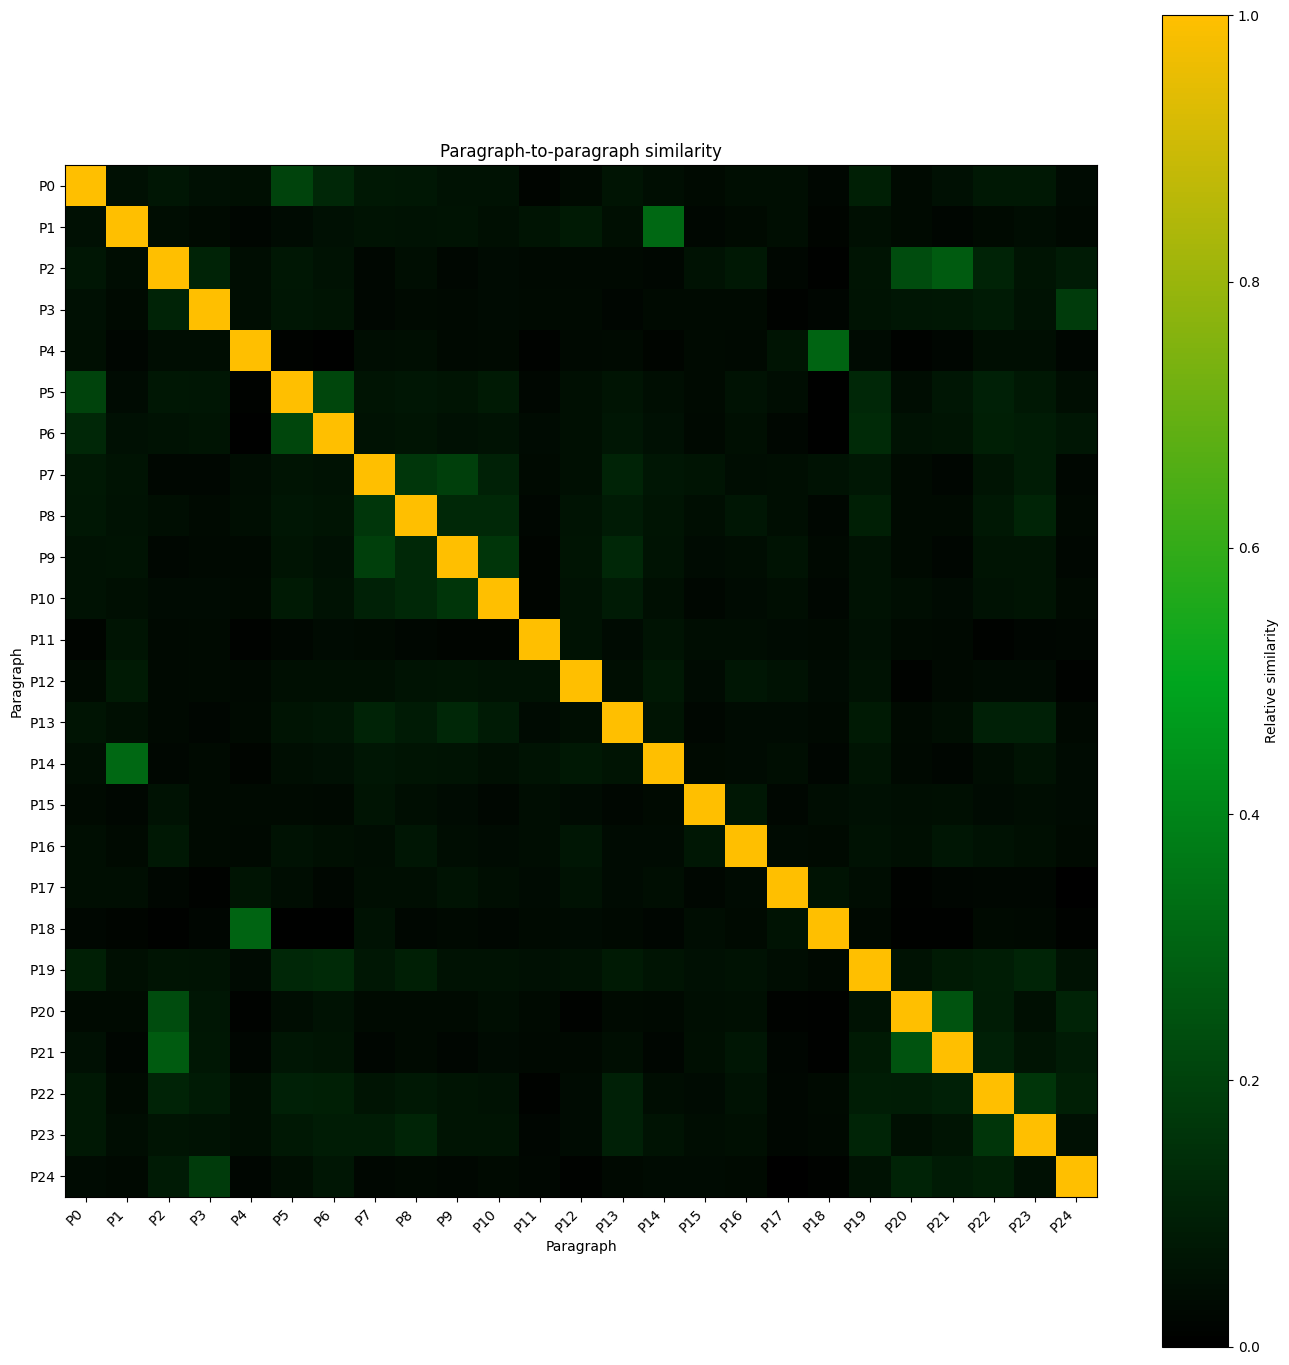

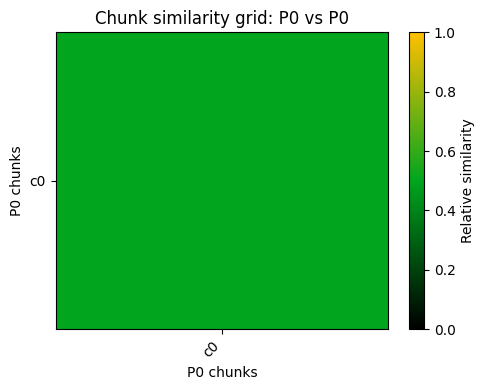


=== P0 vs P0 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
Most similar chunks (score=1.0000): P0 c0 <-> P0 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?


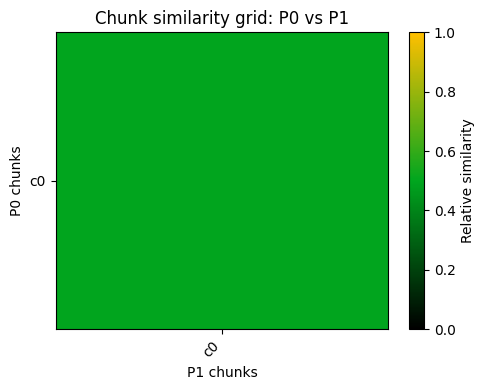


=== P0 vs P1 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P1 text: According to the May 2026 Reporters Without Borders report, what was the primary reason cited for the United States falling to its lowest-ever press freedom ranking of 64th?
Most similar chunks (score=0.4415): P0 c0 <-> P1 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P1 c0: According to the May 2026 Reporters Without Borders report, what was the primary reason cited for the United States falling to its lowest-ever press freedom ranking of 64th?


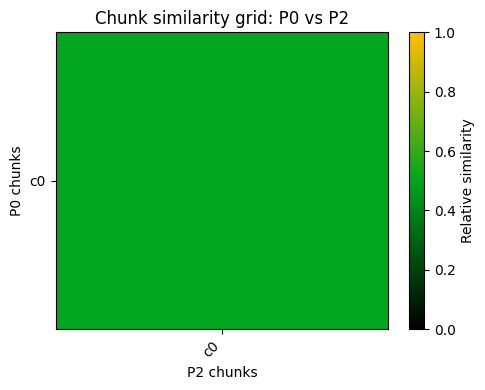


=== P0 vs P2 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P2 text: What were the names of the two specific locations in Lithuania where railway derailments occurred within a three-day period in early May 2026?
Most similar chunks (score=0.4495): P0 c0 <-> P2 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P2 c0: What were the names of the two specific locations in Lithuania where railway derailments occurred within a three-day period in early May 2026?


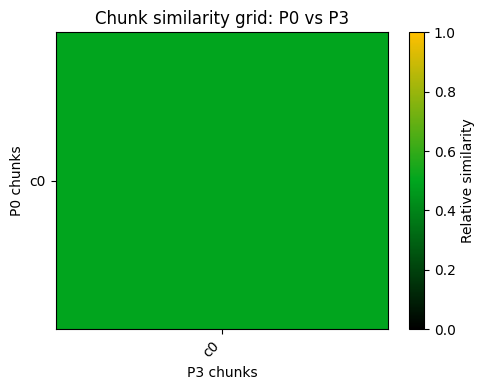


=== P0 vs P3 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P3 text: In the May 2026 IIHF World Championship games, which specific player scored Lithuania's lone goal against Ukraine, and which North American junior team did he previously play for?
Most similar chunks (score=0.4412): P0 c0 <-> P3 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P3 c0: In the May 2026 IIHF World Championship games, which specific player scored Lithuania's lone goal against Ukraine, and which North American junior team did he previously play for?


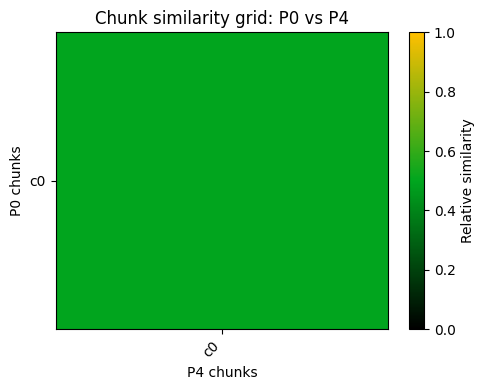


=== P0 vs P4 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P4 text: Which three specific financial and investment firms did Anthropic partner with in May 2026 to launch their new enterprise AI integration company?
Most similar chunks (score=0.4372): P0 c0 <-> P4 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P4 c0: Which three specific financial and investment firms did Anthropic partner with in May 2026 to launch their new enterprise AI integration company?


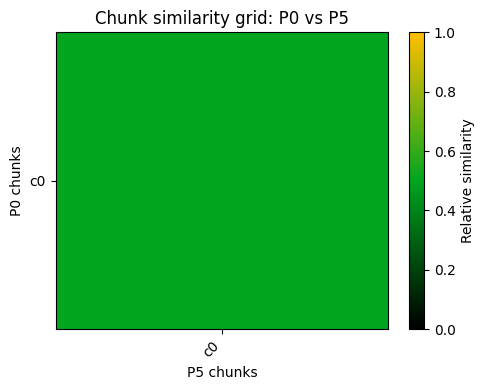


=== P0 vs P5 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P5 text: Russia's Victory Day ceasefire 2026: Russian President Vladimir Putin declared a unilateral two-day ceasefire on May 8-9, 2026, to coincide with Russia's Victory Day celebrations marking the Soviet victory in World Wa...
Most similar chunks (score=0.5313): P0 c0 <-> P5 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P5 c0: Russia's Victory Day ceasefire 2026: Russian President Vladimir Putin declared a unilateral two-day ceasefire on May 8-9, 2026, to coincide with Russia's Victory Day celebrations marking the Soviet victory in World Wa...


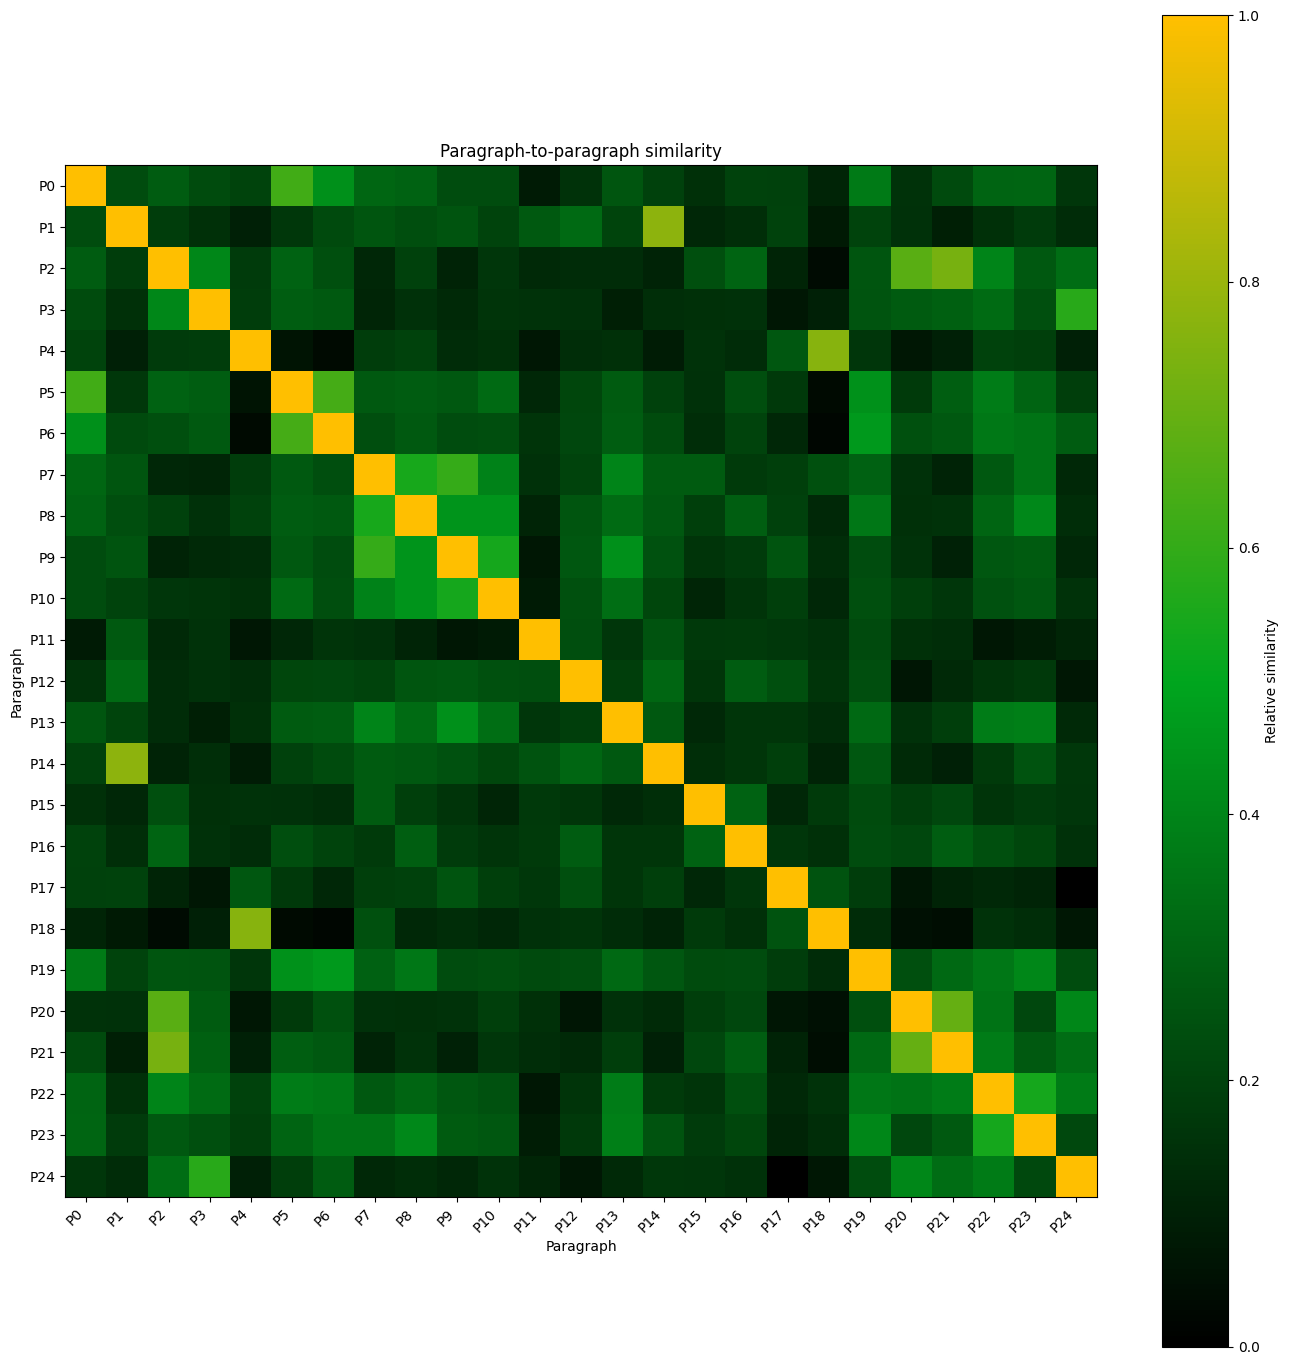

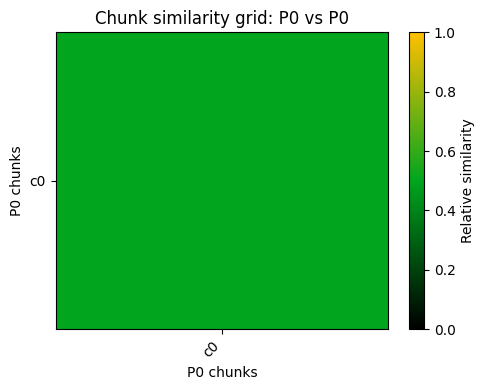


=== P0 vs P0 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
Most similar chunks (score=1.0000): P0 c0 <-> P0 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?


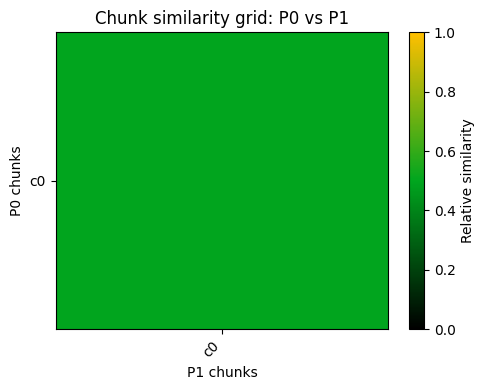


=== P0 vs P1 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P1 text: According to the May 2026 Reporters Without Borders report, what was the primary reason cited for the United States falling to its lowest-ever press freedom ranking of 64th?
Most similar chunks (score=0.1992): P0 c0 <-> P1 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P1 c0: According to the May 2026 Reporters Without Borders report, what was the primary reason cited for the United States falling to its lowest-ever press freedom ranking of 64th?


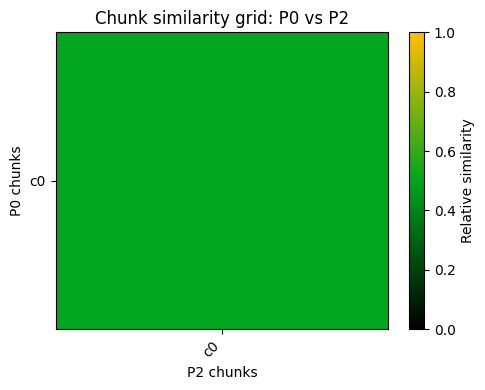


=== P0 vs P2 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P2 text: What were the names of the two specific locations in Lithuania where railway derailments occurred within a three-day period in early May 2026?
Most similar chunks (score=0.2499): P0 c0 <-> P2 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P2 c0: What were the names of the two specific locations in Lithuania where railway derailments occurred within a three-day period in early May 2026?


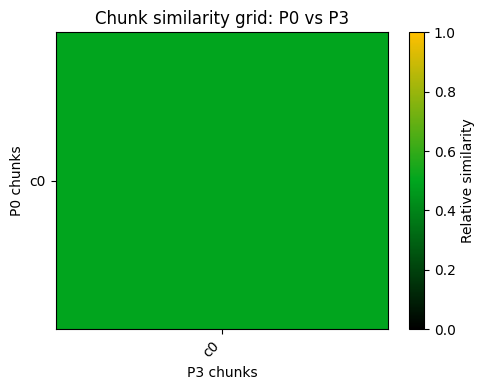


=== P0 vs P3 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P3 text: In the May 2026 IIHF World Championship games, which specific player scored Lithuania's lone goal against Ukraine, and which North American junior team did he previously play for?
Most similar chunks (score=0.1975): P0 c0 <-> P3 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P3 c0: In the May 2026 IIHF World Championship games, which specific player scored Lithuania's lone goal against Ukraine, and which North American junior team did he previously play for?


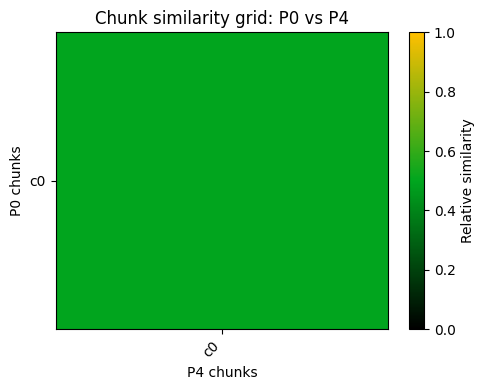


=== P0 vs P4 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P4 text: Which three specific financial and investment firms did Anthropic partner with in May 2026 to launch their new enterprise AI integration company?
Most similar chunks (score=0.1715): P0 c0 <-> P4 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P4 c0: Which three specific financial and investment firms did Anthropic partner with in May 2026 to launch their new enterprise AI integration company?


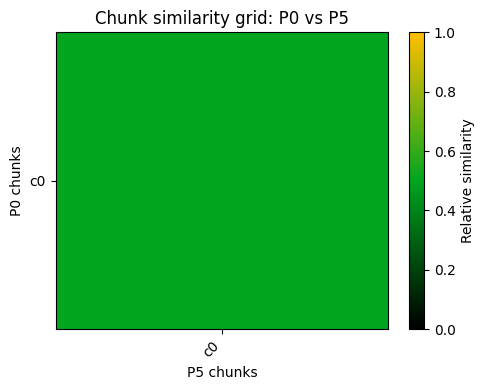


=== P0 vs P5 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P5 text: Russia's Victory Day ceasefire 2026: Russian President Vladimir Putin declared a unilateral two-day ceasefire on May 8-9, 2026, to coincide with Russia's Victory Day celebrations marking the Soviet victory in World Wa...
Most similar chunks (score=0.6108): P0 c0 <-> P5 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P5 c0: Russia's Victory Day ceasefire 2026: Russian President Vladimir Putin declared a unilateral two-day ceasefire on May 8-9, 2026, to coincide with Russia's Victory Day celebrations marking the Soviet victory in World Wa...


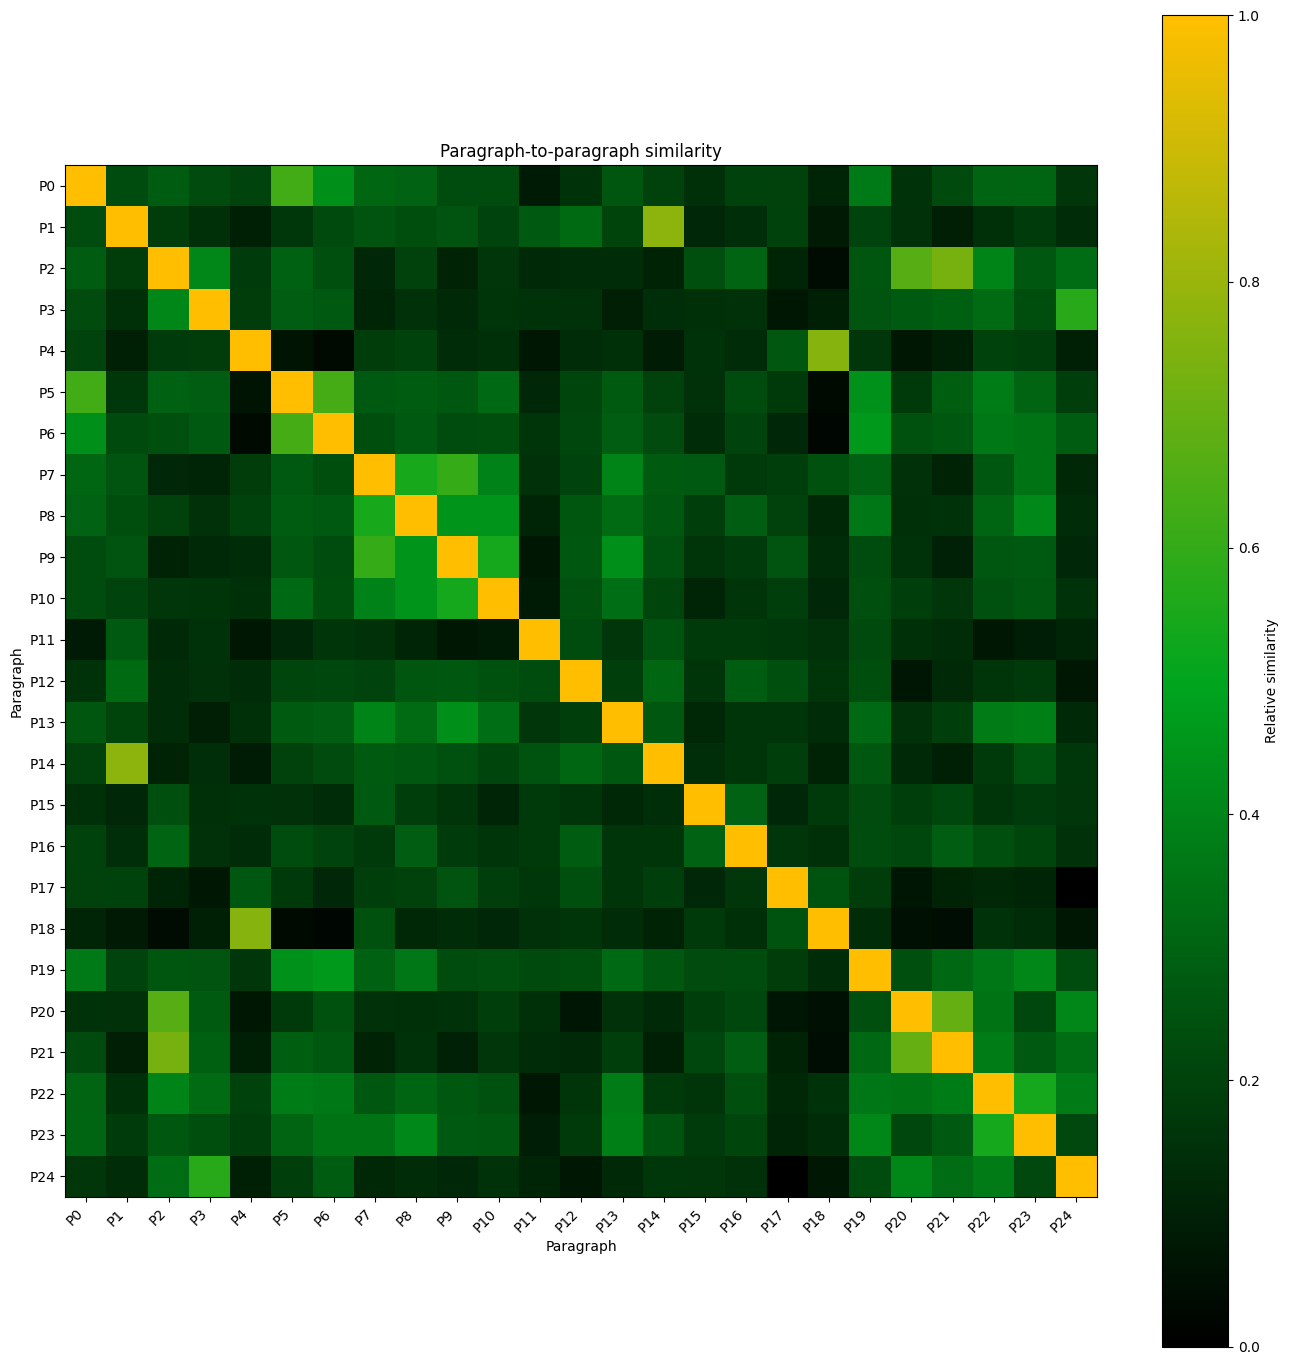

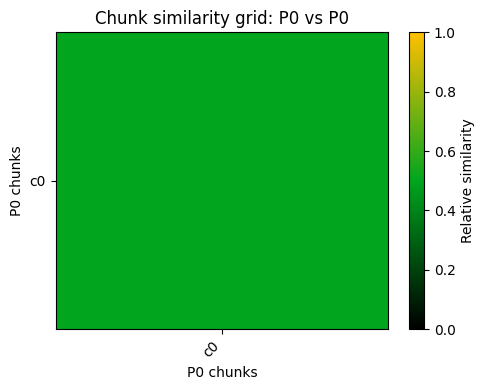


=== P0 vs P0 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
Most similar chunks (score=0.9997): P0 c0 <-> P0 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?


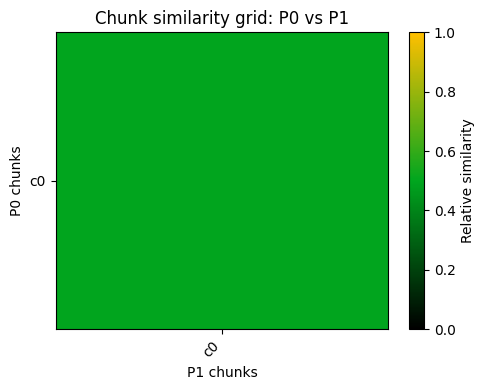


=== P0 vs P1 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P1 text: According to the May 2026 Reporters Without Borders report, what was the primary reason cited for the United States falling to its lowest-ever press freedom ranking of 64th?
Most similar chunks (score=0.1991): P0 c0 <-> P1 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P1 c0: According to the May 2026 Reporters Without Borders report, what was the primary reason cited for the United States falling to its lowest-ever press freedom ranking of 64th?


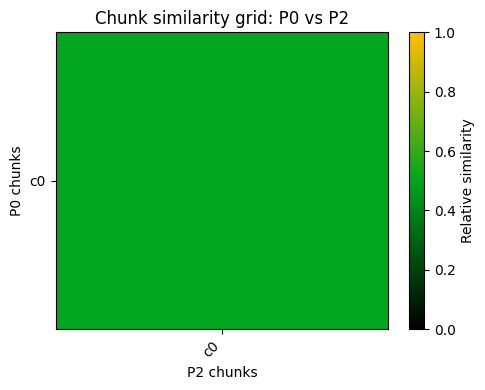


=== P0 vs P2 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P2 text: What were the names of the two specific locations in Lithuania where railway derailments occurred within a three-day period in early May 2026?
Most similar chunks (score=0.2497): P0 c0 <-> P2 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P2 c0: What were the names of the two specific locations in Lithuania where railway derailments occurred within a three-day period in early May 2026?


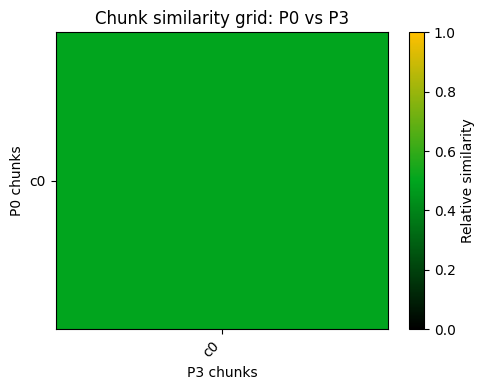


=== P0 vs P3 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P3 text: In the May 2026 IIHF World Championship games, which specific player scored Lithuania's lone goal against Ukraine, and which North American junior team did he previously play for?
Most similar chunks (score=0.1974): P0 c0 <-> P3 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P3 c0: In the May 2026 IIHF World Championship games, which specific player scored Lithuania's lone goal against Ukraine, and which North American junior team did he previously play for?


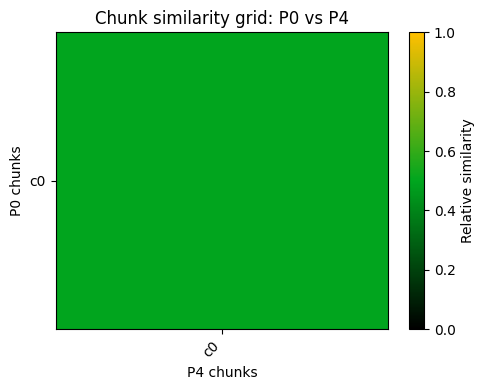


=== P0 vs P4 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P4 text: Which three specific financial and investment firms did Anthropic partner with in May 2026 to launch their new enterprise AI integration company?
Most similar chunks (score=0.1715): P0 c0 <-> P4 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P4 c0: Which three specific financial and investment firms did Anthropic partner with in May 2026 to launch their new enterprise AI integration company?


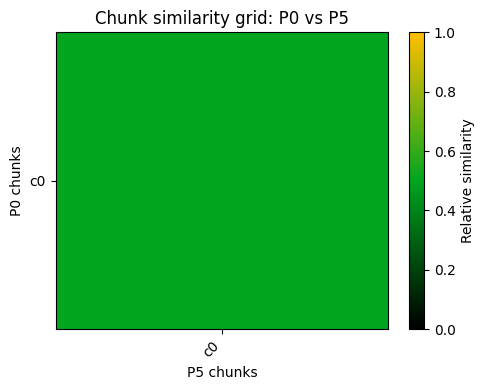


=== P0 vs P5 ===
P0 text: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P5 text: Russia's Victory Day ceasefire 2026: Russian President Vladimir Putin declared a unilateral two-day ceasefire on May 8-9, 2026, to coincide with Russia's Victory Day celebrations marking the Soviet victory in World Wa...
Most similar chunks (score=0.6107): P0 c0 <-> P5 c0
P0 c0: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
P5 c0: Russia's Victory Day ceasefire 2026: Russian President Vladimir Putin declared a unilateral two-day ceasefire on May 8-9, 2026, to coincide with Russia's Victory Day celebrations marking the Soviet victory in World Wa...


In [12]:

similarity_analyzer = SimilarityAnalyzer()
results1 = similarity_analyzer.compare(manager.paragraphs, manager.paragraphs[-3], euclidean_similarity())

similarity_displayer = SimilarityDisplayer()
similarity_displayer.show_paragraph_grid(results1, manager.paragraphs)
similarity_displayer.show_chunk_grids_by_paragraph_pair(results1, manager.paragraphs, max_pairs=6)

results2 = similarity_analyzer.compare(manager.paragraphs, manager.paragraphs[-2], cosine_similarity())
similarity_displayer.show_paragraph_grid(results2, manager.paragraphs)
similarity_displayer.show_chunk_grids_by_paragraph_pair(results2, manager.paragraphs, max_pairs=6)

results3 = similarity_analyzer.compare(manager.paragraphs, manager.paragraphs[-1], dot_similarity())
similarity_displayer.show_paragraph_grid(results3, manager.paragraphs)
similarity_displayer.show_chunk_grids_by_paragraph_pair(results3, manager.paragraphs, max_pairs=6)

In [13]:
model = Model(client)
answer1 = model.generate_text_with_rag(quest_1, results2, count=3)
answer2 = model.generate_text_with_rag(quest_2, results2, count=3)
answer3 = model.generate_text_with_rag(quest_3, results2, count=3)
answer4 = model.generate_text_with_rag(quest_4, results2, count=3)
answer5 = model.generate_text_with_rag(quest_5, results2, count=3)

print(f"Q1: {quest_1_text}\nA1: {answer1}\n")
print(f"Q2: {quest_2_text}\nA2: {answer2}\n")
print(f"Q3: {quest_3_text}\nA3: {answer3}\n")
print(f"Q4: {quest_4_text}\nA4: {answer4}\n")
print(f"Q5: {quest_5_text}\nA5: {answer5}\n")

answer1_no_rag = model.generate_text(quest_1)
answer2_no_rag = model.generate_text(quest_2)
answer3_no_rag = model.generate_text(quest_3)
answer4_no_rag = model.generate_text(quest_4)
answer5_no_rag = model.generate_text(quest_5)

print(f"Q1: {quest_1_text}\nA1 (no RAG): {answer1_no_rag}\n")
print(f"Q2: {quest_2_text}\nA2 (no RAG): {answer2_no_rag}\n")
print(f"Q3: {quest_3_text}\nA3 (no RAG): {answer3_no_rag}\n")
print(f"Q4: {quest_4_text}\nA4 (no RAG): {answer4_no_rag}\n")
print(f"Q5: {quest_5_text}\nA5 (no RAG): {answer5_no_rag}\n")

Q1: Which specific messaging application was used by the Russian Ministry of Defence to announce the May 2026 Victory Day ceasefire?
A1: The cease‑fire was announced via the Russian Ministry of Defence’s own state‑backed messaging platform **MAX**.

Q2: According to the May 2026 Reporters Without Borders report, what was the primary reason cited for the United States falling to its lowest-ever press freedom ranking of 64th?
A2: The report blamed “systematic hostility toward journalists” – in particular a wave of deportations of foreign reporters and the federal government’s drastic cuts to funding for the U.S. Agency for Global Media – as the chief reason the United States slid to its historic low of 64th place.

Q3: What were the names of the two specific locations in Lithuania where railway derailments occurred within a three-day period in early May 2026?
A3: The derailments occurred at **Gudžiūnai** and **Jiesia**.

Q4: In the May 2026 IIHF World Championship games, which specific p